# Notebook 04 — Customer Segmentation using RFM Analysis

## Objective

The objective of this notebook is to segment customers based on their purchasing behavior using RFM (Recency, Frequency, Monetary) analysis. The resulting customer segments will help identify high-value customers, loyal customers, at-risk customers, and other meaningful groups to support business decision-making.

---

### Checklist

- [x]  Introduction
- [x]  Objectives
- [x]  Import libraries
- [x]  Load cleaned dataset
- [x]  Data Preparation
- [x]  Calculate RFM Metrics
- [x]  RFM Scoring
- [x]  Segment customers
- [x]  Save the RFM dataset for subsequent analysis
- [x]  Business Recommendations

# 1. Introduction: Customer Segmentation using RFM Analysis

Customer segmentation is a fundamental technique in data analytics that helps businesses better understand their customers by grouping them based on purchasing behavior.

In this notebook, we apply **RFM (Recency, Frequency, Monetary)** analysis to identify different customer groups according to how recently they purchased, how often they buy, and how much they spend.

The insights obtained from this analysis can support marketing strategies, customer retention efforts, and business decision-making by identifying valuable customers, loyal customers, and those at risk of churning.

## 2. Objectives

The main objectives of this notebook are to:

- Calculate Recency, Frequency, and Monetary (RFM) metrics for each customer.
- Assign RFM scores based on customer purchasing behavior.
- Segment customers into meaningful business groups.
- Analyze the characteristics of each customer segment.
- Generate actionable business insights and recommendations.

## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

In [2]:
# Plot settings
plt.style.use('default')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 4. Load Data

Load the cleaned Online Retail dataset prepared in the previous notebook and perform a quick inspection to ensure it is ready for RFM analysis.

In [3]:
# Load the cleaned dataset
df = pd.read_csv("../Data/cleaned/online_retail_clean.csv")

# Display the first few rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505189 entries, 0 to 505188
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      505189 non-null  int64  
 1   StockCode    505189 non-null  str    
 2   Description  505189 non-null  str    
 3   Quantity     505189 non-null  int64  
 4   InvoiceDate  505189 non-null  str    
 5   Price        505189 non-null  float64
 6   Customer ID  400947 non-null  float64
 7   Country      505189 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 30.8 MB


In [5]:
# Display dataset dimensions
print(f"Dataset shape: {df.shape}")

Dataset shape: (505189, 8)


## 5. Data Preparation

Before calculating the RFM metrics, we verify that the dataset contains all the required columns and that the data is in the correct format for the analysis.

This step helps ensure the reliability of the RFM calculations and avoids unexpected issues later in the notebook.

### 5.1 Standardize Column Names

Rename a few columns to improve consistency and readability throughout the notebook.

In [6]:
# Rename columns for consistency
df = df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
})

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
# Create total purchase amount for each transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

### 5.2 Verify Required Columns

Check whether all columns required for RFM analysis are available in the dataset.

In [8]:
required_columns = [
    'CustomerID',
    'InvoiceDate',
    'InvoiceNo',
    'Quantity',
    'UnitPrice',
    'TotalPrice'
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


### 5.3 Convert InvoiceDate to Datetime

Convert the `InvoiceDate` column to datetime format to enable date-based calculations.

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

datetime64[us]


### 5.4 Handle Missing Customer IDs

RFM analysis requires a valid customer identifier for every transaction. Therefore, transactions with missing `CustomerID` values are removed before calculating customer-level metrics.

In [10]:
# Check missing Customer IDs
missing_customer_ids = df['CustomerID'].isna().sum()

print(f"Missing Customer IDs before removal: {missing_customer_ids}")

# Remove transactions with missing CustomerID
df = df[df['CustomerID'].notna()].copy()

# Verify removal
print(f"Missing Customer IDs after removal: {df['CustomerID'].isna().sum()}")

Missing Customer IDs before removal: 104242
Missing Customer IDs after removal: 0


### 5.5 Check Data Types

Verify that the key columns have appropriate data types for RFM analysis.

In [11]:
df[
    [
        'CustomerID',
        'InvoiceDate',
        'InvoiceNo',
        'Quantity',
        'UnitPrice',
        'TotalPrice'
    ]
].dtypes

CustomerID            float64
InvoiceDate    datetime64[us]
InvoiceNo               int64
Quantity                int64
UnitPrice             float64
TotalPrice            float64
dtype: object

In [12]:
# Convert CustomerID to integer after removing missing values
df['CustomerID'] = df['CustomerID'].astype('int64')

# Verify the updated data type
df['CustomerID'].dtype

dtype('int64')

### 5.6 Validate Transactions

RFM analysis should be based on completed purchase transactions with a positive quantity and unit price. Transactions with zero or negative unit prices are excluded because they do not represent revenue-generating purchases.

In [13]:
# Keep only valid purchase transactions
df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

# Verify the remaining data
print(f"Non-positive Quantity: {(df['Quantity'] <= 0).sum()}")
print(f"Non-positive UnitPrice: {(df['UnitPrice'] <= 0).sum()}")

Non-positive Quantity: 0
Non-positive UnitPrice: 0


### 5.7 Define Snapshot Date

Set the snapshot date as one day after the most recent transaction date. This date serves as the reference point for calculating customer recency.

In [14]:
# Define the reference date for recency calculation
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Snapshot Date: {snapshot_date}")

Snapshot Date: 2010-12-10 20:01:00


## 6. Calculate RFM Metrics

RFM analysis evaluates customer purchasing behavior using three key metrics:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often a customer makes purchases.
- **Monetary (M):** How much a customer has spent.

These metrics form the foundation for customer segmentation.

### 6.1 Build the RFM Table

Aggregate customer transactions to calculate the three RFM metrics for each customer.

In [15]:
rfm = (
    df.groupby('CustomerID')
      .agg(
          Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
          Frequency=('InvoiceNo', 'nunique'),
          Monetary=('TotalPrice', 'sum')
      )
      .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [16]:
# Display summary statistics for the RFM metrics
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


## 7. RFM Scoring

To make customer segmentation more meaningful, the RFM metrics are converted into scores. Each customer receives a score from 1 to 5 for Recency, Frequency, and Monetary based on their relative performance.

These scores are then combined to create an overall RFM score for customer segmentation.

### 7.1 Check RFM Metric Distribution

Before assigning RFM scores, verify that each metric has enough unique values for quantile-based scoring.

In [17]:
# Check the number of unique values in each RFM metric
rfm[['Recency', 'Frequency', 'Monetary']].nunique()

Recency       301
Frequency      64
Monetary     4249
dtype: int64

### 7.2 Assign RFM Scores

Assign a score from 1 to 5 for each RFM metric using quantile-based binning.

- Lower recency receives a higher score.
- Higher frequency receives a higher score.
- Higher monetary value receives a higher score.

In [18]:
# Assign Recency scores (lower recency is better)
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'
)

In [19]:
# Rank Frequency values to reduce duplicate quantile edges
frequency_rank = rfm['Frequency'].rank(method='first')

# Assign Frequency scores (higher frequency is better)
rfm['F_Score'] = pd.qcut(
    frequency_rank,
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [20]:
# Assign Monetary scores (higher monetary value is better)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

In [21]:
# Display the first few rows of the scored RFM table
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,165,11,372.86,2,5,2
1,12347,3,2,1323.32,5,2,4
2,12348,74,1,222.16,2,1,1
3,12349,43,3,2671.14,3,3,5
4,12351,11,1,300.93,5,1,2


In [22]:
# Check the distribution of RFM scores
score_distribution = pd.DataFrame({
    'Recency': rfm['R_Score'].value_counts().sort_index(),
    'Frequency': rfm['F_Score'].value_counts().sort_index(),
    'Monetary': rfm['M_Score'].value_counts().sort_index()
})

score_distribution

,Recency,Frequency,Monetary
1,855,863,863
2,848,862,862
3,850,862,862
4,853,862,862
5,906,863,863


The score distribution shows that customers have been successfully divided into five groups for each RFM metric. The nearly balanced distribution indicates that quantile-based scoring worked as expected.

### 7.3 Create the RFM Score

Combine the individual RFM scores into a single RFM score for each customer. This score provides a compact representation of customer purchasing behavior.

In [23]:
# Combine individual RFM scores into a single RFM score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# Preview the updated RFM table
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,222.16,2,1,1,211
3,12349,43,3,2671.14,3,3,5,335
4,12351,11,1,300.93,5,1,2,512


## 8. Customer Segmentation

### 8.1 Define Segmentation Rules

Customers are assigned to standard RFM segments based on their Recency, Frequency, and Monetary scores. These segments help identify customer groups with similar purchasing behavior and support targeted business strategies.

The segmentation is rule-based and designed to ensure full coverage of all customers. Each customer is assigned to exactly one segment with no remaining uncategorized records.

In [24]:
# Assign customer segments based on RFM scores (improved version)
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    # Champions: best customers
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Loyal Customers: high value & frequent
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'

    # Potential Loyalists: recent but not yet frequent/high value
    elif r >= 4 and f >= 1:
        return 'Potential Loyalists'

    # New Customers: very recent but low engagement
    elif r == 5 and f <= 2:
        return 'New Customers'

    # Promising: medium engagement, room to grow
    elif r >= 3 and f <= 2:
        return 'Promising'

    # Need Attention: medium recency, declining engagement
    elif r == 3 and f <= 3:
        return 'Need Attention'

    # About to Sleep: low engagement, not very recent
    elif r == 2:
        return 'About to Sleep'

    # At Risk: good past customers but inactive now
    elif r <= 2 and f >= 3:
        return 'At Risk'

    # Can't Lose Them: high value but inactive
    elif r == 1 and f >= 4 and m >= 4:
        return "Can't Lose Them"

    # Lost: worst case
    elif r == 1 and f <= 2:
        return 'Lost'

    # IMPORTANT: no "Others" anymore
    return 'Need Attention'

### 8.2 Assign Customer Segments

In [25]:
# Assign a customer segment to each customer
rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Preview the segmented customers
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,165,11,372.86,2,5,2,252,About to Sleep
1,12347,3,2,1323.32,5,2,4,524,Potential Loyalists
2,12348,74,1,222.16,2,1,1,211,About to Sleep
3,12349,43,3,2671.14,3,3,5,335,Loyal Customers
4,12351,11,1,300.93,5,1,2,512,Potential Loyalists


In [26]:
# Summarize customer segments
segment_summary = (
    rfm['Segment']
    .value_counts()
    .rename_axis('Segment')
    .reset_index(name='CustomerCount')
)

segment_summary['Percentage'] = (
    segment_summary['CustomerCount'] / segment_summary['CustomerCount'].sum() * 100
).round(2)

segment_summary

,Segment,CustomerCount,Percentage
0,Champions,926,21.47
1,About to Sleep,848,19.67
2,Loyal Customers,767,17.79
3,Lost,641,14.87
4,Potential Loyalists,503,11.67
5,Promising,343,7.95
6,At Risk,214,4.96
7,Need Attention,70,1.62


The table summarizes the number and percentage of customers in each RFM segment. This overview helps identify the largest customer groups and supports prioritizing marketing strategies.

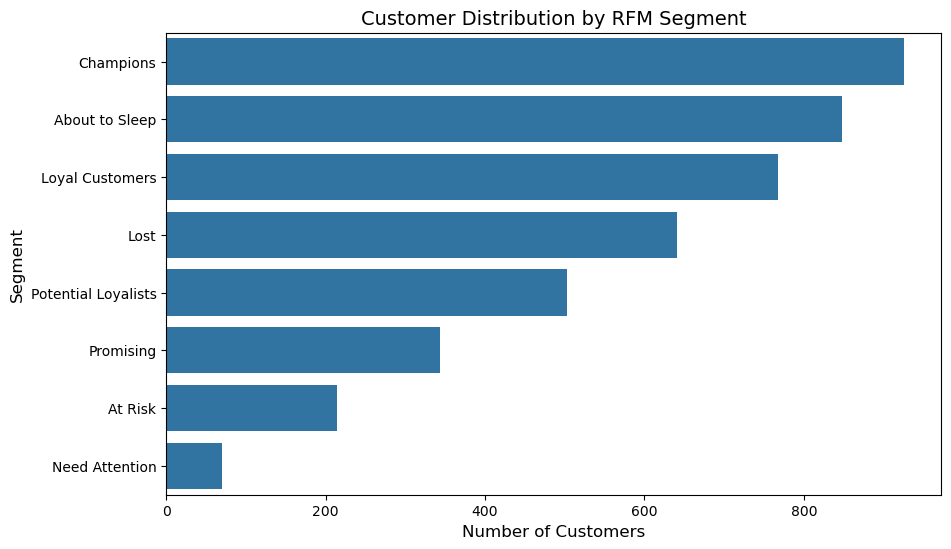

In [27]:
# Plot the distribution of customer segments
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x='CustomerCount',
    y='Segment'
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

plt.show()

The bar chart makes it easier to compare segment sizes visually and highlights the imbalance between the largest and smallest customer groups.

### 8.3 Analyze Segment Characteristics

Summarize the average RFM metrics for each customer segment to better understand their purchasing behavior and business value.

In [28]:
# Calculate the average RFM metrics for each customer segment
segment_analysis = (
    rfm.groupby('Segment')
       .agg(
           CustomerCount=('CustomerID', 'count'),
           AvgRecency=('Recency', 'mean'),
           AvgFrequency=('Frequency', 'mean'),
           AvgMonetary=('Monetary', 'mean')
       )
       .round(2)
       .sort_values('AvgMonetary', ascending=False)
)

segment_analysis

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary
Segment,,,,
Champions,926,13.67,11.68,6168.93
Loyal Customers,767,37.70,4.24,1607.33
At Risk,214,236.54,3.13,1307.29
About to Sleep,848,112.84,2.79,1089.12
Potential Loyalists,503,19.24,1.65,460.82
Promising,343,53.82,1.20,439.84
Lost,641,270.38,1.08,377.35
Need Attention,70,54.36,2.61,358.65


### 8.4 Visualize Customer Segments

Visualize the distribution of customers across the RFM segments to quickly compare the size of each customer group.

In [29]:
# Define the logical order of customer segments
segment_order = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'Promising',
    'Need Attention',
    'About to Sleep',
    'At Risk',
    "Can't Lose Them",
    'Lost'
]

# Apply the custom order
segment_summary['Segment'] = pd.Categorical(
    segment_summary['Segment'],
    categories=segment_order,
    ordered=True
)

segment_summary = segment_summary.sort_values('Segment')

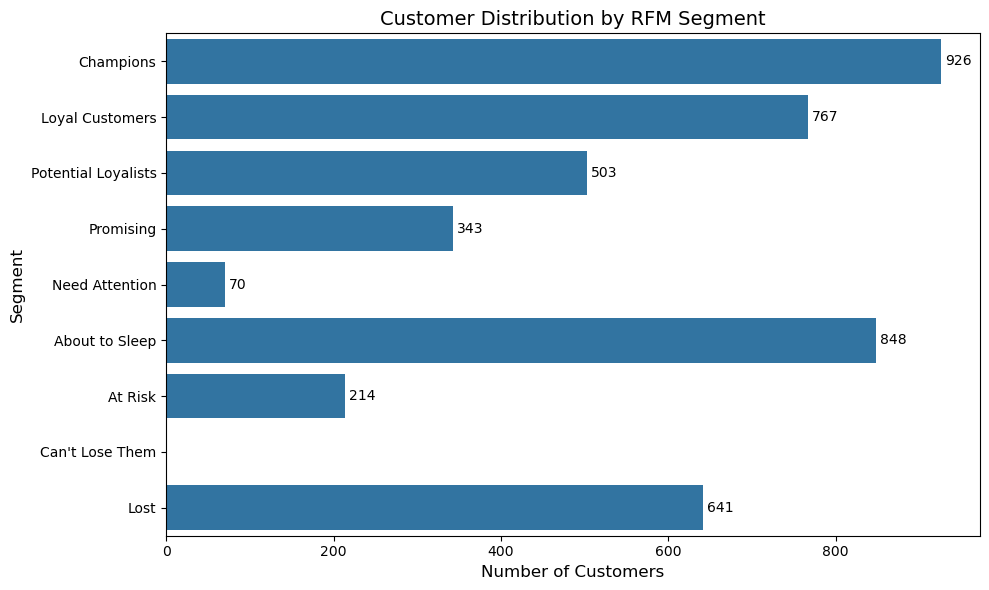

In [30]:
# Create the bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=segment_summary,
    x='CustomerCount',
    y='Segment'
)

# Add customer counts to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

plt.tight_layout()
plt.show()

### 8.5 Interpretation

The customer distribution reveals a diverse customer base across different RFM segments.

Champions represent the largest customer group, indicating that many customers have purchased recently, buy frequently, and generate high revenue. Loyal Customers also account for a significant portion of the customer base, suggesting a strong foundation of repeat buyers.

On the other hand, a considerable number of customers fall into the About to Sleep and Lost segments. These groups may benefit from targeted re-engagement campaigns to prevent further customer churn.

Overall, the segmentation highlights opportunities to strengthen customer retention while maximizing the value of high-performing customer groups.

## 9. Business Recommendations

Based on the RFM segmentation, the following actions can help improve customer engagement and maximize business value.

| Segment             | Recommended Action                                                                                                     |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| Champions           | Reward loyalty with exclusive offers and early access to new products.                                                 |
| Loyal Customers     | Encourage higher spending through personalized recommendations and loyalty programs.                                   |
| Potential Loyalists | Convert them into loyal customers with targeted promotions.                                                            |
| Promising           | Maintain engagement with personalized email campaigns.                                                                 |
| Need Attention      | Re-engage with limited-time offers before they become inactive.                                                        |
| About to Sleep      | Send reminder campaigns or discounts to encourage another purchase.                                                    |
| At Risk             | Launch win-back campaigns with personalized incentives.                                                                |
| Lost                | Consider low-cost reactivation campaigns or exclude them from premium marketing efforts if inactive for a long period. |


## 10. Save the RFM and processed dataset for subsequent analysis

In [31]:
df.to_csv("../data/processed/online_retail_processed.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [32]:
# Save the RFM dataset for the next notebook
rfm.to_csv("../data/processed/customer_rfm.csv", index=False)

print("Customer RFM dataset saved successfully.")

Customer RFM dataset saved successfully.
